 # **INTRODUCTION**
> In this competition your task is to predict whether a passenger was transported to an alternate dimension during the Spaceship Titanic's collision with the spacetime anomaly. To help you make these predictions, you're given a set of personal records recovered from the ship's damaged computer system.
*In this notebook I have used Logistic Regression and Random Forset Classification methods to predict which passengers are transported to another world.*

# **IMPORTING DATA**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
space_train=pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
space_test=pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")
sample=pd.read_csv("/kaggle/input/spaceship-titanic/sample_submission.csv")

# **DATA EXPLORATION**

In [3]:
space_train.shape

(8693, 14)

In [4]:
space_test.shape

(4277, 13)

In [5]:
space_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
space_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [7]:
space_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [8]:
space_train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [9]:
space_train.PassengerId.nunique()/space_train.shape[0]

1.0

In [10]:
space_train.Transported.value_counts()

True     4378
False    4315
Name: Transported, dtype: int64

In [11]:
space_train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [12]:
space_test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [13]:
# Replacing the null values 
space_train["HomePlanet"].fillna(method="ffill",inplace=True)
space_train["CryoSleep"].fillna(method="ffill",inplace=True)
space_train["Cabin"].fillna(method="ffill",inplace=True)
space_train["Destination"].fillna(method="ffill",inplace=True)
space_train["Age"].fillna(space_train["Age"].mean(),inplace=True)
space_train["VIP"].fillna(method="ffill",inplace=True)
space_train["RoomService"].fillna(space_train["RoomService"].mean(),inplace=True)
space_train["FoodCourt"].fillna(space_train["FoodCourt"].mean(),inplace=True)
space_train["ShoppingMall"].fillna(space_train["ShoppingMall"].mean(),inplace=True)
space_train["Spa"].fillna(space_train["Spa"].mean(),inplace=True)
space_train["VRDeck"].fillna(space_train["VRDeck"].mean(),inplace=True)
space_train["Name"].fillna(method="ffill",inplace=True)

In [14]:
# Rechecking after eliminating null values
space_train.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [15]:
# Replacing the null values 
space_test["HomePlanet"].fillna(method="ffill",inplace=True)
space_test["CryoSleep"].fillna(method="ffill",inplace=True)
space_test["Cabin"].fillna(method="ffill",inplace=True)
space_test["Destination"].fillna(method="ffill",inplace=True)
space_test["Age"].fillna(space_test["Age"].mean(),inplace=True)
space_test["VIP"].fillna(method="ffill",inplace=True)
space_test["RoomService"].fillna(space_test["RoomService"].mean(),inplace=True)
space_test["FoodCourt"].fillna(space_test["FoodCourt"].mean(),inplace=True)
space_test["ShoppingMall"].fillna(space_test["ShoppingMall"].mean(),inplace=True)
space_test["Spa"].fillna(space_test["Spa"].mean(),inplace=True)
space_test["VRDeck"].fillna(space_test["VRDeck"].mean(),inplace=True)
space_test["Name"].fillna(method="ffill",inplace=True)

In [16]:
# Rechecking after eliminating null values
space_test.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
dtype: int64

# **DATA VISUALIZATION**

<AxesSubplot:title={'center':'Distribution of Transported Passengers'}, ylabel='Transported'>

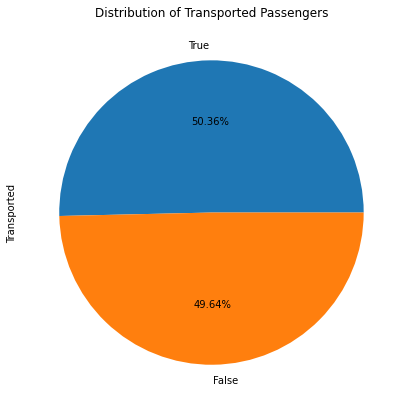

In [17]:
plt.figure(figsize=(7,7))
plt.title("Distribution of Transported Passengers")
space_train["Transported"].value_counts().plot(kind="pie",autopct='%1.2f%%')

There is not much difference in the distribution of Transported and non transported passengers. Hence, the data is unbaised. 

Text(0.5, 1.0, 'Transported successfully from Home Planet')

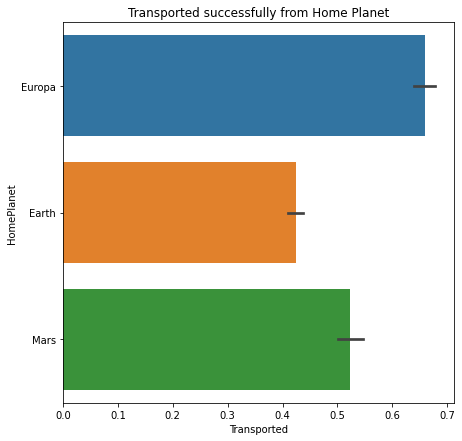

In [18]:
plt.figure(figsize=(7,7))
sns.barplot(x="Transported",y="HomePlanet",data=space_train)
plt.title("Transported successfully from Home Planet")

Maximum no of passengers transported are from planet Eupora

<AxesSubplot:title={'center':' Passengers Confined to Cabins'}, ylabel='CryoSleep'>

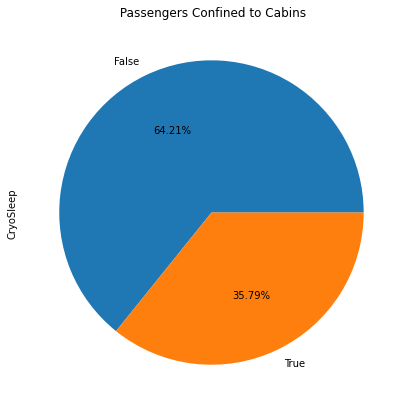

In [19]:
plt.figure(figsize=(7,7))
plt.title(" Passengers Confined to Cabins")
space_train["CryoSleep"].value_counts().plot(kind="pie",autopct='%1.2f%%')

Text(0.5, 1.0, 'Confined Passengers Transported')

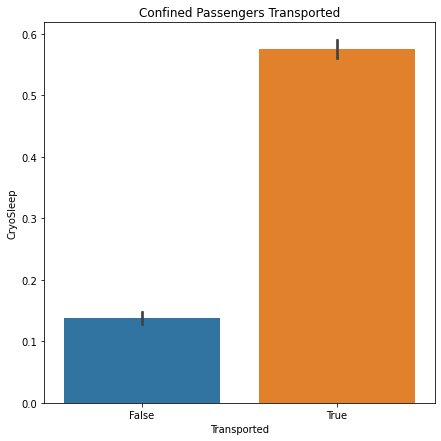

In [20]:
plt.figure(figsize=(7,7))
sns.barplot(x="Transported",y="CryoSleep",data=space_train)
plt.title("Confined Passengers Transported")

Maximum confined passengers are transported.

<AxesSubplot:ylabel='Destination'>

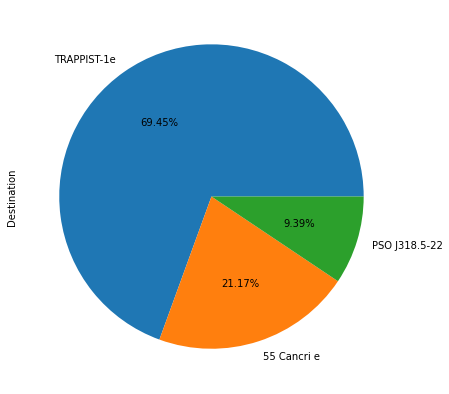

In [21]:
plt.figure(figsize=(7,7))
space_train["Destination"].value_counts().plot(kind="pie",autopct='%1.2f%%')

<AxesSubplot:xlabel='Transported', ylabel='Destination'>

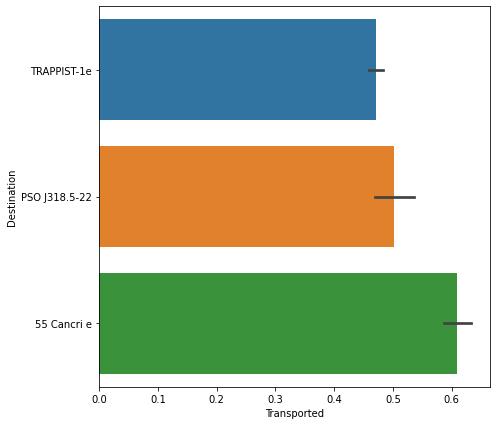

In [22]:
plt.figure(figsize=(7,7))
sns.barplot(x="Transported",y="Destination",data=space_train)

Maximum transported to 55 Cancri e

<AxesSubplot:ylabel='Side'>

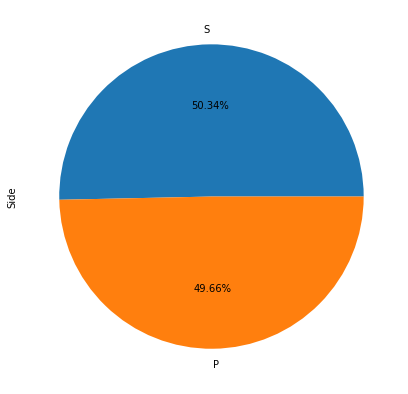

In [23]:
# splitting the cabin to Side : Port(P)  or Standard(S)
space_train["Side"]=space_train["Cabin"].str.split("/").str[2] 
plt.figure(figsize=(7,7))
space_train["Side"].value_counts().plot(kind="pie",autopct='%1.2f%%')

<Figure size 504x504 with 0 Axes>

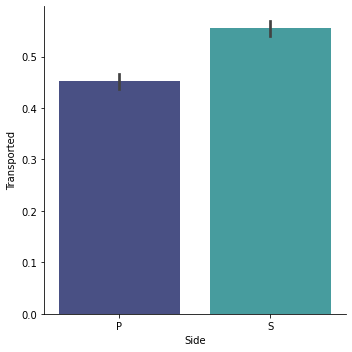

In [24]:
plt.figure(figsize=(7,7))
sns.catplot(x="Side",y="Transported",kind="bar",palette="mako",data=space_train)

<AxesSubplot:ylabel='Deck'>

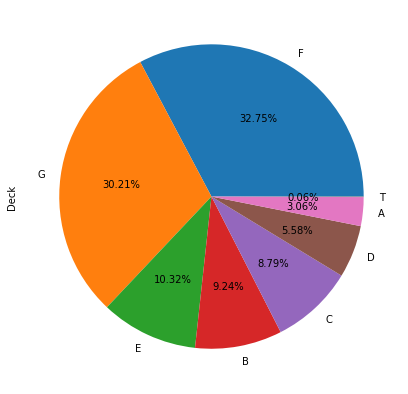

In [25]:
space_train["Deck"]=space_train["Cabin"].str.split("/").str[0] 
plt.figure(figsize=(7,7))
space_train["Deck"].value_counts().plot(kind="pie",autopct='%1.2f%%')

<Figure size 504x504 with 0 Axes>

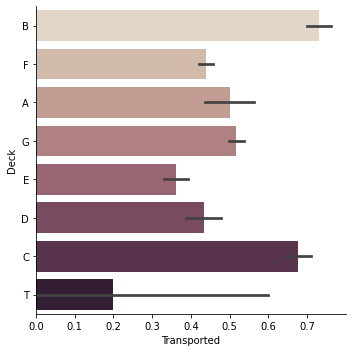

In [26]:
plt.figure(figsize=(7,7))
sns.catplot(x="Transported",y="Deck",kind="bar",palette="ch:.25",data=space_train)

<Figure size 720x720 with 0 Axes>

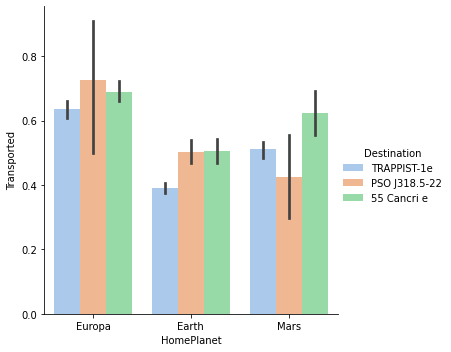

In [27]:
plt.figure(figsize=(10,10))
sns.catplot(x="HomePlanet",y="Transported",hue="Destination",kind="bar",palette="pastel",data=space_train)

<Figure size 720x720 with 0 Axes>

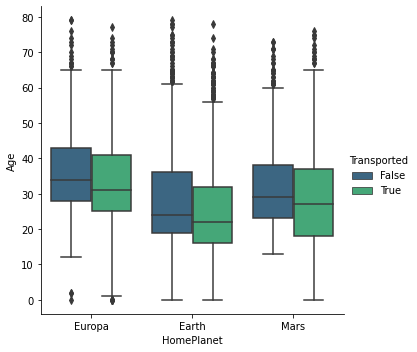

In [28]:
plt.figure(figsize=(10,10))
sns.catplot(x="HomePlanet",y="Age",hue="Transported",kind="box",palette="viridis",data=space_train)

<AxesSubplot:ylabel='VIP'>

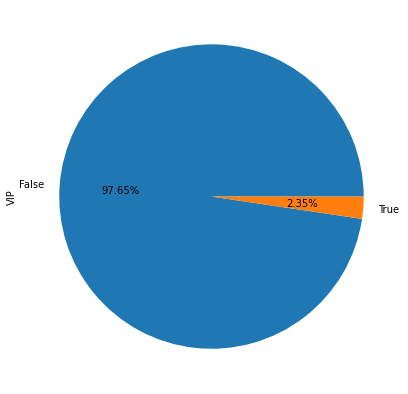

In [29]:
plt.figure(figsize=(7,7))
space_train["VIP"].value_counts().plot(kind="pie",autopct='%1.2f%%')

<Figure size 720x720 with 0 Axes>

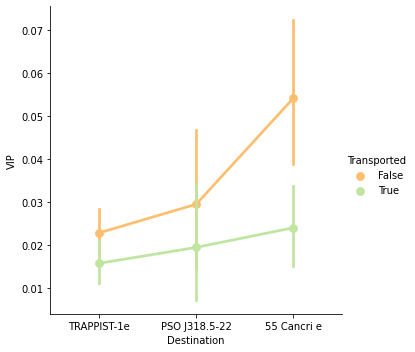

In [30]:
plt.figure(figsize=(10,10))
sns.catplot(x="Destination",y="VIP",hue="Transported",kind="point",palette="Spectral",data=space_train)

<Figure size 720x720 with 0 Axes>

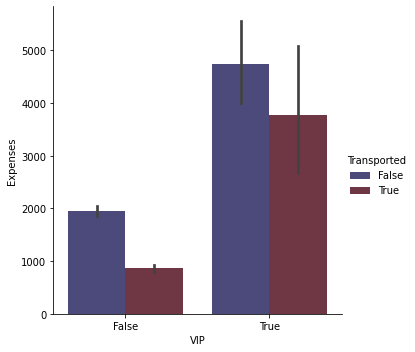

In [31]:
space_train["Expenses"]=space_train["RoomService"]+space_train["FoodCourt"]+space_train["ShoppingMall"]+space_train["Spa"]+space_train["VRDeck"]
plt.figure(figsize=(10,10))
sns.catplot(x="VIP",y="Expenses",hue="Transported",kind="bar",palette="icefire",data=space_train)

<Figure size 720x720 with 0 Axes>

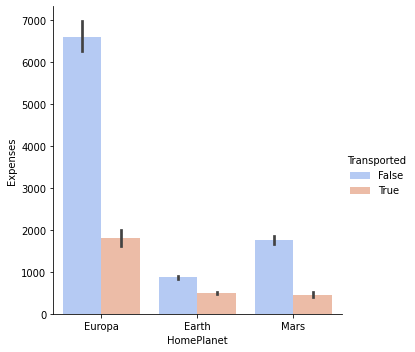

In [32]:
plt.figure(figsize=(10,10))
sns.catplot(x="HomePlanet",y="Expenses",hue="Transported",kind="bar",palette="coolwarm",data=space_train)

<AxesSubplot:xlabel='Age', ylabel='Expenses'>

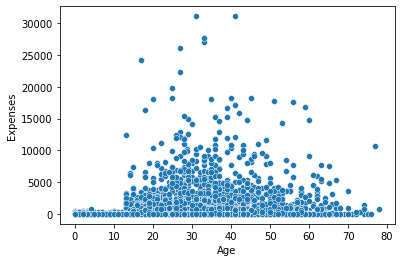

In [33]:
sns.scatterplot(x='Age',y='Expenses',data=space_train[space_train.Transported==True])

<AxesSubplot:xlabel='Side', ylabel='Expenses'>

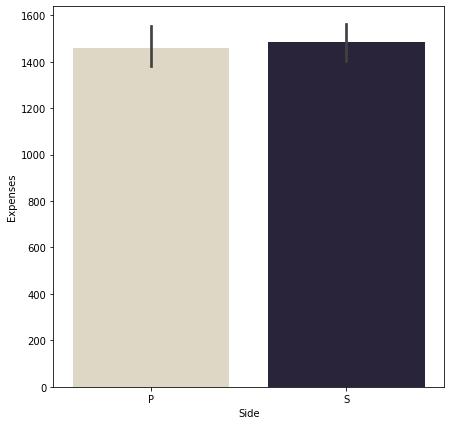

In [34]:
plt.figure(figsize=(7,7))
sns.barplot(x="Side",y="Expenses",palette="ch:s=-.2,r=.6",data=space_train)

# **DATA ENCODING**

In [35]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
for x in [i for i in space_train.columns if len(space_train[i].unique())==2]:
    print(x, space_train[x].unique())
    space_train[x]= label_encoder.fit_transform(space_train[x])
    

CryoSleep [False  True]
VIP [False  True]
Transported [False  True]
Side ['P' 'S']


In [36]:
space_train.drop(["HomePlanet","Cabin","Destination","Name","Side","Expenses","Deck"],axis=1,inplace=True)

In [37]:
space_train.head()

,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0001_01,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0
1,0002_01,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1
2,0003_01,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0
3,0003_02,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0
4,0004_01,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1


In [38]:
#Check Variables after Encoding
[[x, space_train[x].unique()] for x in [i for i in space_train.columns if len(space_train[i].unique())<10]]

[['CryoSleep', array([0, 1])],
 ['VIP', array([0, 1])],
 ['Transported', array([0, 1])]]

In [39]:
space_test.drop(["HomePlanet","Cabin","Destination","Name"],axis=1,inplace=True)

In [40]:
space_test.head()

,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0013_01,True,27.0,False,0.0,0.0,0.0,0.0,0.0
1,0018_01,False,19.0,False,0.0,9.0,0.0,2823.0,0.0
2,0019_01,True,31.0,False,0.0,0.0,0.0,0.0,0.0
3,0021_01,False,38.0,False,0.0,6652.0,0.0,181.0,585.0
4,0023_01,False,20.0,False,10.0,0.0,635.0,0.0,0.0


In [41]:
label_encoder=LabelEncoder()
for x in [i for i in space_test.columns if len(space_test[i].unique())==2]:
    print(x, space_test[x].unique())
    space_test[x]= label_encoder.fit_transform(space_test[x])

CryoSleep [ True False]
VIP [False  True]


In [42]:
#Check Variables after Encoding
[[x, space_test[x].unique()] for x in [i for i in space_test.columns if len(space_test[i].unique())<10]]

[['CryoSleep', array([1, 0])], ['VIP', array([0, 1])]]

In [43]:
space_train.head()

,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0001_01,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0
1,0002_01,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1
2,0003_01,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0
3,0003_02,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0
4,0004_01,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1


# **SPLITTING DATA**

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report,accuracy_score
from sklearn.metrics import roc_curve , auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [45]:
## Defining variables X,y 
x_train= space_train.drop(["Transported","PassengerId"],axis=1)
x_test=space_test.drop(["PassengerId"],axis=1)
Y_train=space_train["Transported"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(x_train, Y_train, test_size = 0.25, random_state = 0)

In [47]:
print("shape of X_train:",X_train.shape)
print("shape of y_train:",y_train.shape[0])

shape of X_train: (6519, 8)
shape of y_train: 6519


In [48]:
## Scaling the data 
sc= StandardScaler()
X_train = sc.fit_transform(X_train)
X_test=sc.transform(X_test)
X_train=pd.DataFrame(X_train,columns=x_train.columns)
X_test=pd.DataFrame(X_test,columns=x_test.columns)

# **LOGISTIC REGRESSION**

In [49]:
## Training the model using Logistic Regression
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [50]:
## Predicting data
y_pred=model.predict(X_test)

In [51]:
## classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.76      0.77      1077
           1       0.77      0.80      0.79      1097

    accuracy                           0.78      2174
   macro avg       0.78      0.78      0.78      2174
weighted avg       0.78      0.78      0.78      2174



Confusion matrix is 
 [[817 260]
 [216 881]]


Text(42.0, 0.5, 'predicted label')

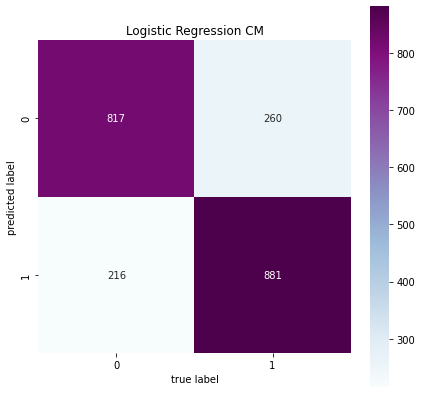

In [52]:
## confusion matrix
conf_mat=confusion_matrix(y_test,y_pred)
print("Confusion matrix is \n",conf_mat)

## plotting confusion matrix
plt.figure(figsize=(7,7))
plt.title("Logistic Regression CM")
sns.heatmap(conf_mat, square=True,cmap="BuPu",annot=True,fmt='d')
plt.xlabel('true label')
plt.ylabel('predicted label')

 **CONCLUSION**
   *    true values : 1698
   *    false values: 476

In [53]:
## accuracy score
print("accuracy score : ",accuracy_score(y_test,y_pred))

## percentage accurate
print("accuracy:",round(100*accuracy_score(y_test,y_pred)),"%")

accuracy score :  0.781048758049678
accuracy: 78 %


In [54]:
## Prediction using predict_proba 

y_pred_proba = model.predict_proba(X_test)[:,1]

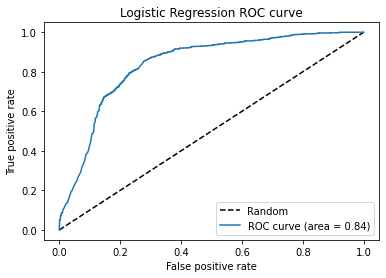

In [55]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc=auc(fpr,tpr)
#Now Draw ROC using fpr , tpr
plt.plot([0, 1], [0, 1], 'k--',label='Random')
plt.plot(fpr,tpr,label='ROC curve (area = %0.2f)' %roc_auc)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Logistic Regression ROC curve')
plt.legend(loc='best')

# **RANDOM FOREST CLASSIFICATION**

In [56]:
from sklearn.ensemble import RandomForestClassifier

In [57]:
#Apply RandomForest Algorithm
random_classifier= RandomForestClassifier(max_depth=20,random_state=2)
random_classifier.fit(X_train,y_train)

RandomForestClassifier(max_depth=20, random_state=2)

In [58]:
y_pred_rnd= random_classifier.predict(X_test)

In [59]:
#Classification Report
print(classification_report(y_test,y_pred_rnd))

              precision    recall  f1-score   support

           0       0.79      0.74      0.77      1077
           1       0.76      0.81      0.79      1097

    accuracy                           0.78      2174
   macro avg       0.78      0.78      0.78      2174
weighted avg       0.78      0.78      0.78      2174



Confusion matrix is 
 [[802 275]
 [208 889]]


Text(42.0, 0.5, 'predicted label')

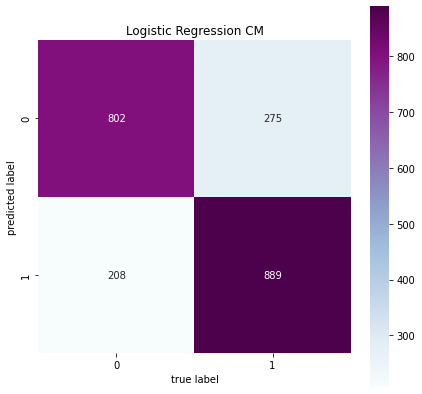

In [60]:
## confusion matrix
conf_mat=confusion_matrix(y_test,y_pred_rnd)
print("Confusion matrix is \n",conf_mat)

## plotting confusion matrix
plt.figure(figsize=(7,7))
plt.title("Logistic Regression CM")
sns.heatmap(conf_mat, square=True,cmap="BuPu",annot=True,fmt='d')
plt.xlabel('true label')
plt.ylabel('predicted label')

 **CONCLUSION**
   *    true values : 1691
   *    false values: 483

In [61]:
## accuracy score
print("accuracy score : ",accuracy_score(y_test,y_pred_rnd))

## percentage accurate
print("accuracy:", round(100*accuracy_score(y_test,y_pred_rnd)),"%")

accuracy score :  0.7778288868445262
accuracy: 78 %


In [62]:
y_pred_proba_rnd=random_classifier.predict_proba(X_test)[:,1]

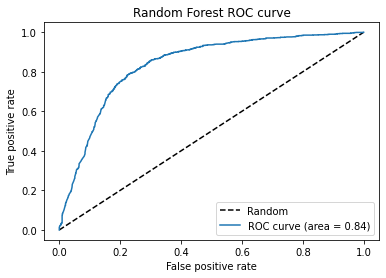

In [63]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rnd)
roc_auc=auc(fpr,tpr)
#Now Draw ROC using fpr , tpr
plt.plot([0, 1], [0, 1], 'k--',label='Random')
plt.plot(fpr,tpr,label='ROC curve (area = %0.2f)' %roc_auc)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Random Forest ROC curve')
plt.legend(loc='best')

# **MODEL SELECTION**
> Both the models have same accuracy rate. Hence, we can use any one of them.
Here, I am using Logistic Regression because it has more true values than Random Forest Classification. 

In [64]:
y_final=model.predict(x_test)

In [65]:
y_final

array([0, 0, 0, ..., 0, 1, 0])

# **SUBMISSION**

In [66]:
sub=pd.DataFrame({'PassengerId':space_test["PassengerId"],"Transported":y_final.astype('bool')})

In [67]:
sub.to_csv('submission.csv',index=False)
pd.read_csv('submission.csv')

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,False
4273,9269_01,True
4274,9271_01,False
4275,9273_01,True
